# Proposed Hybrid Model (VGG16+EfficientNetB0-> CA->GRU-> classiification) IQ-OTHNCCD lung cancer dataset

[INFO] Loading data...
[INFO] Dataset loaded with 1097 images and 3 classes.

[INFO] Starting Fold 1
Epoch 1/50
55/55 [==============================] - 13s 155ms/step - loss: 0.9076 - accuracy: 0.6100 - val_loss: 0.7298 - val_accuracy: 0.8182 - lr: 1.0000e-05
Epoch 2/50
55/55 [==============================] - 6s 112ms/step - loss: 0.5226 - accuracy: 0.8233 - val_loss: 0.3812 - val_accuracy: 0.8727 - lr: 1.0000e-05
Epoch 3/50
55/55 [==============================] - 6s 102ms/step - loss: 0.3457 - accuracy: 0.8700 - val_loss: 0.3368 - val_accuracy: 0.8682 - lr: 1.0000e-05
Epoch 4/50
55/55 [==============================] - 6s 112ms/step - loss: 0.3387 - accuracy: 0.8757 - val_loss: 0.2797 - val_accuracy: 0.8909 - lr: 1.0000e-05
Epoch 5/50
55/55 [==============================] - 6s 111ms/step - loss: 0.2899 - accuracy: 0.8905 - val_loss: 0.2465 - val_accuracy: 0.9045 - lr: 1.0000e-05
Epoch 6/50
55/55 [==============================] - 6s 101ms/step - loss: 0.2490 - accuracy: 0.8951 - v

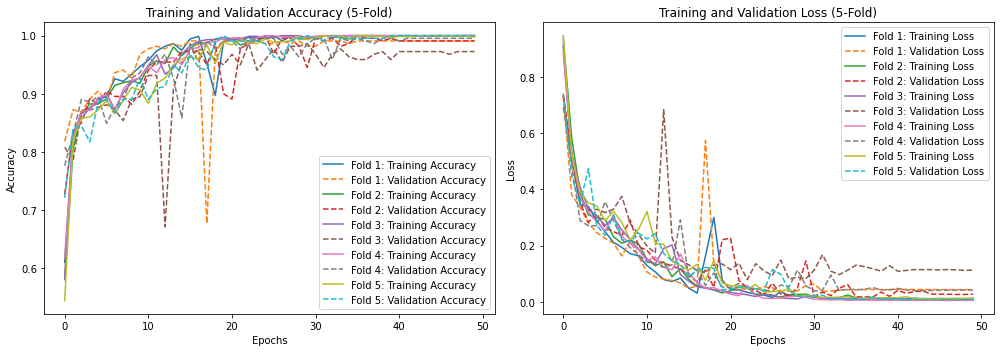

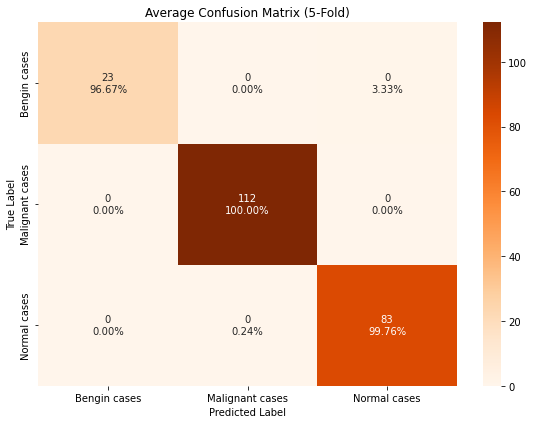


[INFO] Average metrics across all folds (mean ± std):
Accuracy: 0.9954 ± 0.0050
Cohen's Kappa: 0.9921 ± 0.0086
Precision: 0.9955 ± 0.0049
Recall: 0.9954 ± 0.0050
F1-score: 0.9954 ± 0.0051
AUC (macro): 0.9979 ± 0.0018


In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0, VGG16
from tensorflow.keras.layers import (
    Input, Concatenate, GlobalAveragePooling2D, Dense, Multiply,
    Reshape, GRU, LSTM, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score, 
    precision_score, recall_score, accuracy_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ========== Preprocessing Functions ==========

def gaussian_filter(image, kernel=(5, 5), sigma=0):
    return cv2.GaussianBlur(image, kernel, sigma)

def z_score_norm(img):
    return (img - np.mean(img)) / (np.std(img) + 1e-8)

def median_filter(image, kernel_size=5):
    return cv2.medianBlur(image, kernel_size)

def preprocess_image(img, img_size=(224, 224)):
    img = cv2.resize(img, img_size)
    img = median_filter(img)
    # img = gaussian_filter(img)  # Optional Gaussian filter
    img = z_score_norm(img)
    return img

def load_dataset(folder, img_size=(224, 224), max_images_per_class=None):
    images = []
    labels = []
    class_names = sorted([d for d in os.listdir(folder) if os.path.isdir(os.path.join(folder, d))])

    for label, class_folder in enumerate(class_names):
        path = os.path.join(folder, class_folder)
        files = sorted(os.listdir(path))
        if max_images_per_class:
            files = files[:max_images_per_class]
        for file in files:
            img_path = os.path.join(path, file)
            img = cv2.imread(img_path)
            if img is not None:
                processed_img = preprocess_image(img, img_size)
                images.append(processed_img)
                labels.append(label)

    X = np.array(images, dtype=np.float32)
    y = np.array(labels, dtype=np.int32)
    return X, y, class_names

# ========== Model Definition ==========

def channel_attention(inputs, reduction_ratio=8):
    channels = inputs.shape[-1]

    avg_pool = GlobalAveragePooling2D()(inputs)
    dense1 = Dense(channels // reduction_ratio, activation='relu')(avg_pool)
    dense2 = Dense(channels, activation='sigmoid')(dense1)

    scale = Multiply()([inputs, Reshape((1, 1, channels))(dense2)])
    return scale

def build_model(input_shape=(224, 224, 3), num_classes=3, rnn_type='GRU'):
    input_tensor = Input(shape=input_shape)

    base1 = EfficientNetB0(include_top=False, input_tensor=input_tensor, weights='imagenet')
    base2 = VGG16(include_top=False, input_tensor=input_tensor, weights='imagenet')

    # Freeze base models initially
    for layer in base1.layers:
        layer.trainable = True
    for layer in base2.layers:
        layer.trainable = True

    feat1 = base1.output
    feat2 = base2.output
    x = Concatenate(axis=-1)([feat1, feat2])

    x = channel_attention(x)
    x = GlobalAveragePooling2D()(x)
    x = Reshape((1, -1))(x)

    if rnn_type.upper() == 'GRU':
        x = GRU(128, return_sequences=False)(x)
    elif rnn_type.upper() == 'LSTM':
        x = LSTM(128, return_sequences=False)(x)
    else:
        raise ValueError("rnn_type must be 'GRU' or 'LSTM'")

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# ========== Plotting Functions ==========

def plot_all_histories(histories,filename='G:/Dataset/Multimodal Lung Manuscript/Training plot/VGG16_EfficientNetB0_GRU_training_metrics.png'):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    for i, h in enumerate(histories):
        plt.plot(h.history['accuracy'], label=f'Fold {i+1}: Training Accuracy')
        plt.plot(h.history['val_accuracy'], label=f'Fold {i+1}: Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy (5-Fold)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    for i, h in enumerate(histories):
        plt.plot(h.history['loss'], label=f'Fold {i+1}: Training Loss')
        plt.plot(h.history['val_loss'], label=f'Fold {i+1}: Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss (5-Fold)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(filename, dpi=300)
    plt.tight_layout()
    plt.show()
    
    plt.close()

def plot_average_confusion_matrix(conf_matrices, class_names,filename='G:/Dataset/Multimodal Lung Manuscript/CM/VGG16_EfficientNetB0_GRU_training_metrics.png'):
    avg_cm = np.mean(conf_matrices, axis=0)
    cm_sum = np.sum(avg_cm, axis=1, keepdims=True)
    cm_perc = avg_cm.astype('float') / cm_sum.astype(float) * 100

    annot = np.empty_like(avg_cm).astype(str)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            c = int(avg_cm[i, j])
            p = cm_perc[i, j]
            annot[i, j] = f'{c}\n{p:.2f}%'

    plt.figure(figsize=(8, 6))
    sns.heatmap(avg_cm, annot=annot, fmt='', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Average Confusion Matrix (5-Fold)')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    
    plt.close()

# ========== Main ==========

if __name__ == "__main__":
    dataset_path = "G:/Dataset/The IQ-OTHNCCD lung cancer dataset"  # <-- Change this!
    img_size = (224, 224)

    print("[INFO] Loading data...")
    X, y, class_names = load_dataset(dataset_path, img_size)
    num_classes = len(class_names)
    print(f"[INFO] Dataset loaded with {len(X)} images and {num_classes} classes.")

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    histories = []
    all_y_true = []
    all_y_pred = []
    fold_conf_matrices = []

    # Initialize lists for metrics
    accuracies = []
    kappas = []
    precisions = []
    recalls = []
    f1_scores = []
    aucs = []

    fold = 1
    for train_idx, val_idx in kfold.split(X, y):
        print(f"\n[INFO] Starting Fold {fold}")

        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        y_train_cat = to_categorical(y_train, num_classes)
        y_val_cat = to_categorical(y_val, num_classes)

        model = build_model(input_shape=img_size + (3,), num_classes=num_classes, rnn_type='GRU')
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, decay=1e-4),
                      loss='categorical_crossentropy', metrics=['accuracy'])

        checkpoint_path = f"G:/Dataset/Multimodal Lung Manuscript/model/VGG16_EfficientNetB0_GRU_model_Fold{fold}.h5"
        checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max')
        early = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, min_lr=1e-7, verbose=1)

        history = model.fit(
            X_train, y_train_cat,
            validation_data=(X_val, y_val_cat),
            epochs=50,
            batch_size=16,
            callbacks=[checkpoint, early, reduce_lr],
            verbose=1
        )
        histories.append(history)

        # Load best weights and evaluate
        model = tf.keras.models.load_model(checkpoint_path)
        preds = model.predict(X_val)
        y_pred = np.argmax(preds, axis=1)

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

        # Binarize true labels for AUC
        y_val_bin = label_binarize(y_val, classes=range(num_classes))

        acc = accuracy_score(y_val, y_pred)
        kappa = cohen_kappa_score(y_val, y_pred)
        prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
        rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_val, y_pred, average='weighted', zero_division=0)

        # Calculate multiclass AUC (macro) - use predicted probabilities and binarized true labels
        try:
            auc = roc_auc_score(y_val_bin, preds, multi_class='ovo', average='macro')
        except Exception as e:
            print(f"[WARNING] Could not compute AUC: {e}")
            auc = float('nan')

        accuracies.append(acc)
        kappas.append(kappa)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)
        aucs.append(auc)

        print(f"[INFO] Fold {fold} Metrics:")
        print(f"Accuracy: {acc:.4f}")
        print(f"Cohen's Kappa: {kappa:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1-score: {f1:.4f}")
        print(f"AUC (macro): {auc:.4f}")

        print(f"\n[INFO] Fold {fold} Classification Report:")
        print(classification_report(y_val, y_pred, target_names=class_names, digits=3))

        cm = confusion_matrix(y_val, y_pred)
        
        
        
        fold_conf_matrices.append(cm)

        fold += 1

    # Plot training history for all folds
    plot_all_histories(histories)

    # Plot average confusion matrix across folds
    plot_average_confusion_matrix(fold_conf_matrices, class_names)

    # Report average metrics across all folds with std
    print("\n[INFO] Average metrics across all folds (mean ± std):")
    print(f"Accuracy: {np.nanmean(accuracies):.4f} ± {np.nanstd(accuracies):.4f}")
    print(f"Cohen's Kappa: {np.nanmean(kappas):.4f} ± {np.nanstd(kappas):.4f}")
    print(f"Precision: {np.nanmean(precisions):.4f} ± {np.nanstd(precisions):.4f}")
    print(f"Recall: {np.nanmean(recalls):.4f} ± {np.nanstd(recalls):.4f}")
    print(f"F1-score: {np.nanmean(f1_scores):.4f} ± {np.nanstd(f1_scores):.4f}")
    print(f"AUC (macro): {np.nanmean(aucs):.4f} ± {np.nanstd(aucs):.4f}")

# Proposed Model for  5 class lung and colon cancer classification on LC25000

[INFO] Getting file paths and labels...
[INFO] Total samples: 25000, Classes: 5

[INFO] Starting Fold 1
Epoch 1/50
1250/1250 [==============================] - 165s 125ms/step - loss: 0.2538 - accuracy: 0.9287 - val_loss: 0.0700 - val_accuracy: 0.9808 - lr: 1.0000e-05
Epoch 2/50
1250/1250 [==============================] - 156s 124ms/step - loss: 0.0916 - accuracy: 0.9763 - val_loss: 0.0564 - val_accuracy: 0.9814 - lr: 1.0000e-05
Epoch 3/50
1250/1250 [==============================] - 155s 124ms/step - loss: 0.0565 - accuracy: 0.9857 - val_loss: 0.0238 - val_accuracy: 0.9938 - lr: 1.0000e-05
Epoch 4/50
1250/1250 [==============================] - 154s 123ms/step - loss: 0.0391 - accuracy: 0.9902 - val_loss: 0.0268 - val_accuracy: 0.9908 - lr: 1.0000e-05
Epoch 5/50
1250/1250 [==============================] - 156s 124ms/step - loss: 0.0255 - accuracy: 0.9939 - val_loss: 0.0154 - val_accuracy: 0.9960 - lr: 1.0000e-05
Epoch 6/50
1250/1250 [==============================] - 155s 124ms/step

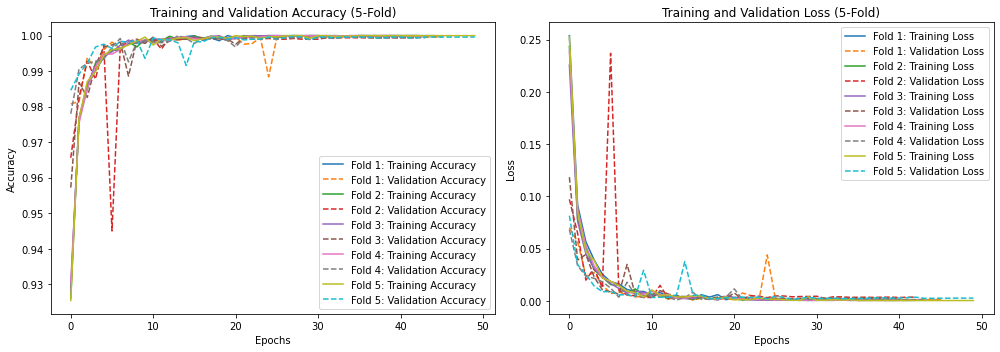

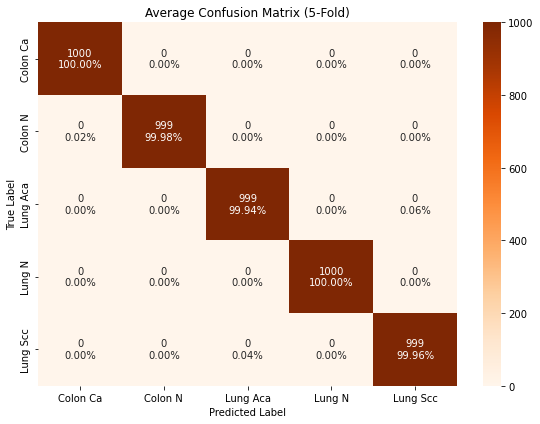


[INFO] Average metrics across all folds (mean ± std):
Accuracy: 0.9998 ± 0.0001
Cohen's Kappa: 0.9997 ± 0.0002
Precision: 0.9998 ± 0.0001
Recall: 0.9998 ± 0.0001
F1-score: 0.9998 ± 0.0001
AUC (macro): 1.0000 ± 0.0000


In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0, VGG16
from tensorflow.keras.layers import (
    Input, Concatenate, GlobalAveragePooling2D, Dense, Multiply,
    Reshape, GRU, LSTM, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    precision_score, recall_score, accuracy_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ================== Preprocessing ==================

def gaussian_filter(image, kernel=(5, 5), sigma=0):
    return cv2.GaussianBlur(image, kernel, sigma)

def z_score_norm(img):
    return (img - np.mean(img)) / (np.std(img) + 1e-8)

def median_filter(image, kernel_size=5):
    return cv2.medianBlur(image, kernel_size)

def preprocess_image_cv2(img):
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.uint8).numpy()
    img = median_filter(img, kernel_size=5)
    img = img.astype(np.float32)
    img = z_score_norm(img)
    return img.astype(np.float32)

def preprocess_image_tf(img_path):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.image.convert_image_dtype(img, tf.uint8)
    img = tf.py_function(preprocess_image_cv2, [img], Tout=tf.float32)
    img.set_shape([224, 224, 3])
    return img

# ================== Dataset loader ==================

def get_filepaths_and_labels(dataset_path):
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    filepaths = []
    labels = []
    for label, class_folder in enumerate(class_names):
        folder = os.path.join(dataset_path, class_folder)
        files = sorted(os.listdir(folder))
        for file in files:
            filepaths.append(os.path.join(folder, file))
            labels.append(label)
    return filepaths, labels, class_names

def create_dataset(filepaths, labels, batch_size, shuffle=True):
    filepaths = tf.constant(filepaths)
    labels = tf.constant(labels)

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(filepaths))

    def load_and_preprocess(path, label):
        img = preprocess_image_tf(path)
        label_cat = tf.one_hot(label, depth=num_classes)
        return img, label_cat

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

# ================== Model definition ==================

def channel_attention(inputs, reduction_ratio=8):
    channels = inputs.shape[-1]

    avg_pool = GlobalAveragePooling2D()(inputs)
    dense1 = Dense(channels // reduction_ratio, activation='relu')(avg_pool)
    dense2 = Dense(channels, activation='sigmoid')(dense1)

    scale = Multiply()([inputs, Reshape((1, 1, channels))(dense2)])
    return scale

def build_model(input_shape=(224, 224, 3), num_classes=5, rnn_type='GRU'):
    input_tensor = Input(shape=input_shape)

    base1 = EfficientNetB0(include_top=False, input_tensor=input_tensor, weights='imagenet')
    base2 = VGG16(include_top=False, input_tensor=input_tensor, weights='imagenet')

    for layer in base1.layers:
        layer.trainable = True
    for layer in base2.layers:
        layer.trainable = True

    feat1 = base1.output
    feat2 = base2.output
    x = Concatenate(axis=-1)([feat1, feat2])

    x = channel_attention(x)
    x = GlobalAveragePooling2D()(x)
    x = Reshape((1, -1))(x)

    if rnn_type.upper() == 'GRU':
        x = GRU(128, return_sequences=False)(x)
    elif rnn_type.upper() == 'LSTM':
        x = LSTM(128, return_sequences=False)(x)
    else:
        raise ValueError("rnn_type must be 'GRU' or 'LSTM'")

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# ================== Plotting ==================

def plot_all_histories(histories, filename='G:/Dataset/Multimodal Lung Manuscript/Training plot/5_class_LC25000_VGG16_EfficientNetB0_GRU_training_metrics.png'):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    for i, h in enumerate(histories):
        plt.plot(h.history['accuracy'], label=f'Fold {i+1}: Training Accuracy')
        plt.plot(h.history['val_accuracy'], label=f'Fold {i+1}: Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy (5-Fold)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    for i, h in enumerate(histories):
        plt.plot(h.history['loss'], label=f'Fold {i+1}: Training Loss')
        plt.plot(h.history['val_loss'], label=f'Fold {i+1}: Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss (5-Fold)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(filename, dpi=300)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_average_confusion_matrix(conf_matrices, class_names, filename='G:/Dataset/Multimodal Lung Manuscript/CM/5_class_LC25000_VGG16_EfficientNetB0_GRU_training_metrics.png'):
    avg_cm = np.mean(conf_matrices, axis=0)
    cm_sum = np.sum(avg_cm, axis=1, keepdims=True)
    cm_perc = avg_cm.astype('float') / cm_sum.astype(float) * 100

    annot = np.empty_like(avg_cm).astype(str)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            c = int(avg_cm[i, j])
            p = cm_perc[i, j]
            annot[i, j] = f'{c}\n{p:.2f}%'

    plt.figure(figsize=(8, 6))
    sns.heatmap(avg_cm, annot=annot, fmt='', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Average Confusion Matrix (5-Fold)')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# ================== Main ==================

if __name__ == "__main__":
    dataset_path = "G:/Dataset/LC25000/5 class/All"  # your path here
    batch_size = 16
    epochs = 5

    print("[INFO] Getting file paths and labels...")
    filepaths, labels, class_names = get_filepaths_and_labels(dataset_path)
    num_classes = len(class_names)

    labels = np.array(labels)
    filepaths = np.array(filepaths)

    print(f"[INFO] Total samples: {len(filepaths)}, Classes: {num_classes}")

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    histories = []
    all_y_true = []
    all_y_pred = []
    fold_conf_matrices = []

    accuracies = []
    kappas = []
    precisions = []
    recalls = []
    f1_scores = []
    aucs = []

    import gc
    from tensorflow.keras import backend as K

    fold = 1
    for train_idx, val_idx in kfold.split(filepaths, labels):
        print(f"\n[INFO] Starting Fold {fold}")

        train_paths, val_paths = filepaths[train_idx], filepaths[val_idx]
        train_labels, val_labels = labels[train_idx], labels[val_idx]

        train_ds = create_dataset(train_paths, train_labels, batch_size, shuffle=True)
        val_ds = create_dataset(val_paths, val_labels, batch_size, shuffle=False)

        model = build_model(input_shape=(224, 224, 3), num_classes=num_classes, rnn_type='GRU')
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, decay=1e-4),
                      loss='categorical_crossentropy', metrics=['accuracy'])

        checkpoint_path = f"G:/Dataset/Multimodal Lung Manuscript/model/5_class_LC25000_VGG16_EfficientNetB0_GRU_model_Fold{fold}.h5"
        checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max')
        early = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, min_lr=1e-7, verbose=1)

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=50,
            callbacks=[checkpoint, early, reduce_lr],
            verbose=1
        )
        histories.append(history)

        model = tf.keras.models.load_model(checkpoint_path)

        preds = model.predict(val_ds)
        y_pred = np.argmax(preds, axis=1)

        all_y_true.extend(val_labels)
        all_y_pred.extend(y_pred)

        y_val_bin = label_binarize(val_labels, classes=range(num_classes))

        acc = accuracy_score(val_labels, y_pred)
        kappa = cohen_kappa_score(val_labels, y_pred)
        prec = precision_score(val_labels, y_pred, average='weighted', zero_division=0)
        rec = recall_score(val_labels, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(val_labels, y_pred, average='weighted', zero_division=0)

        try:
            auc = roc_auc_score(y_val_bin, preds, multi_class='ovo', average='macro')
        except Exception as e:
            print(f"[WARNING] Could not compute AUC: {e}")
            auc = float('nan')

        accuracies.append(acc)
        kappas.append(kappa)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)
        aucs.append(auc)

        print(f"[INFO] Fold {fold} Metrics:")
        print(f"Accuracy: {acc:.4f}")
        print(f"Cohen's Kappa: {kappa:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1-score: {f1:.4f}")
        print(f"AUC (macro): {auc:.4f}")

        print(f"\n[INFO] Fold {fold} Classification Report:")
        print(classification_report(val_labels, y_pred, target_names=class_names, digits=3))

        cm = confusion_matrix(val_labels, y_pred)
        fold_conf_matrices.append(cm)

        fold += 1

        del model
        K.clear_session()
        gc.collect()

    plot_all_histories(histories)
    plot_average_confusion_matrix(fold_conf_matrices, class_names)

    print("\n[INFO] Average metrics across all folds (mean ± std):")
    print(f"Accuracy: {np.nanmean(accuracies):.4f} ± {np.nanstd(accuracies):.4f}")
    print(f"Cohen's Kappa: {np.nanmean(kappas):.4f} ± {np.nanstd(kappas):.4f}")
    print(f"Precision: {np.nanmean(precisions):.4f} ± {np.nanstd(precisions):.4f}")
    print(f"Recall: {np.nanmean(recalls):.4f} ± {np.nanstd(recalls):.4f}")
    print(f"F1-score: {np.nanmean(f1_scores):.4f} ± {np.nanstd(f1_scores):.4f}")
    print(f"AUC (macro): {np.nanmean(aucs):.4f} ± {np.nanstd(aucs):.4f}")

# Proposed Model for 3 Class lung cancer classification

[INFO] Getting file paths and labels...
[INFO] Total samples: 15000, Classes: 3

[INFO] Starting Fold 1
Epoch 1/50
750/750 [==============================] - 102s 130ms/step - loss: 0.2170 - accuracy: 0.9252 - val_loss: 0.1235 - val_accuracy: 0.9497 - lr: 1.0000e-05
Epoch 2/50
750/750 [==============================] - 97s 129ms/step - loss: 0.0817 - accuracy: 0.9729 - val_loss: 0.0643 - val_accuracy: 0.9810 - lr: 1.0000e-05
Epoch 3/50
750/750 [==============================] - 96s 128ms/step - loss: 0.0501 - accuracy: 0.9843 - val_loss: 0.0602 - val_accuracy: 0.9803 - lr: 1.0000e-05
Epoch 4/50
750/750 [==============================] - 99s 132ms/step - loss: 0.0371 - accuracy: 0.9896 - val_loss: 0.0933 - val_accuracy: 0.9703 - lr: 1.0000e-05
Epoch 5/50
750/750 [==============================] - 101s 135ms/step - loss: 0.0202 - accuracy: 0.9942 - val_loss: 0.0107 - val_accuracy: 0.9973 - lr: 1.0000e-05
Epoch 6/50
750/750 [==============================] - 101s 134ms/step - loss: 0.0170

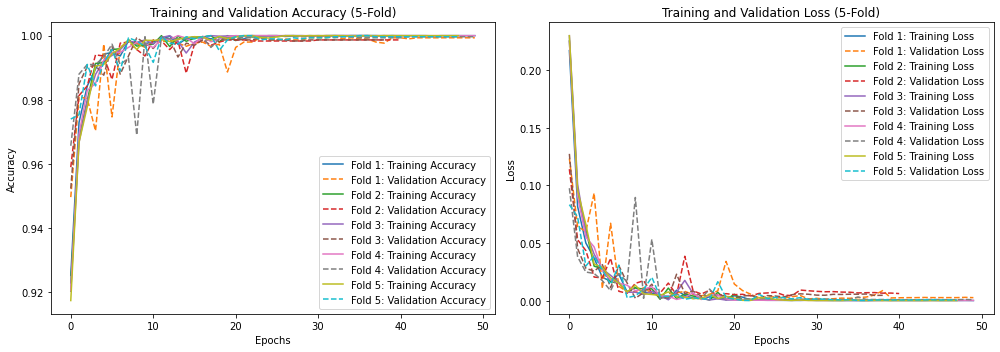

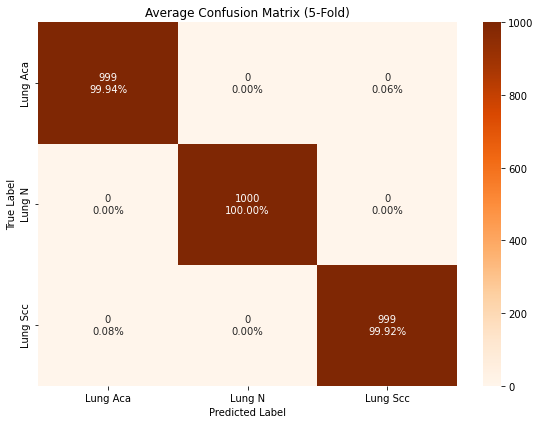


[INFO] Average metrics across all folds (mean ± std):
Accuracy: 0.9995 ± 0.0005
Cohen's Kappa: 0.9993 ± 0.0007
Precision: 0.9995 ± 0.0005
Recall: 0.9995 ± 0.0005
F1-score: 0.9995 ± 0.0005
AUC (macro): 1.0000 ± 0.0000


In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import EfficientNetB0, VGG16
from tensorflow.keras.layers import (
    Input, Concatenate, GlobalAveragePooling2D, Dense, Multiply,
    Reshape, GRU, LSTM, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, cohen_kappa_score,
    precision_score, recall_score, accuracy_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# ================== Preprocessing ==================

def gaussian_filter(image, kernel=(5, 5), sigma=0):
    return cv2.GaussianBlur(image, kernel, sigma)

def z_score_norm(img):
    return (img - np.mean(img)) / (np.std(img) + 1e-8)

def median_filter(image, kernel_size=5):
    return cv2.medianBlur(image, kernel_size)

def preprocess_image_cv2(img):
    img = tf.image.resize(img, (224, 224))
    img = tf.cast(img, tf.uint8).numpy()
    img = median_filter(img, kernel_size=5)
    img = img.astype(np.float32)
    img = z_score_norm(img)
    return img.astype(np.float32)

def preprocess_image_tf(img_path):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.image.convert_image_dtype(img, tf.uint8)
    img = tf.py_function(preprocess_image_cv2, [img], Tout=tf.float32)
    img.set_shape([224, 224, 3])
    return img

# ================== Dataset loader ==================

def get_filepaths_and_labels(dataset_path):
    class_names = sorted([d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))])
    filepaths = []
    labels = []
    for label, class_folder in enumerate(class_names):
        folder = os.path.join(dataset_path, class_folder)
        files = sorted(os.listdir(folder))
        for file in files:
            filepaths.append(os.path.join(folder, file))
            labels.append(label)
    return filepaths, labels, class_names

def create_dataset(filepaths, labels, batch_size, shuffle=True):
    filepaths = tf.constant(filepaths)
    labels = tf.constant(labels)

    dataset = tf.data.Dataset.from_tensor_slices((filepaths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(filepaths))

    def load_and_preprocess(path, label):
        img = preprocess_image_tf(path)
        label_cat = tf.one_hot(label, depth=num_classes)
        return img, label_cat

    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

# ================== Model definition ==================

def channel_attention(inputs, reduction_ratio=8):
    channels = inputs.shape[-1]

    avg_pool = GlobalAveragePooling2D()(inputs)
    dense1 = Dense(channels // reduction_ratio, activation='relu')(avg_pool)
    dense2 = Dense(channels, activation='sigmoid')(dense1)

    scale = Multiply()([inputs, Reshape((1, 1, channels))(dense2)])
    return scale

def build_model(input_shape=(224, 224, 3), num_classes=3, rnn_type='GRU'):
    input_tensor = Input(shape=input_shape)

    base1 = EfficientNetB0(include_top=False, input_tensor=input_tensor, weights='imagenet')
    base2 = VGG16(include_top=False, input_tensor=input_tensor, weights='imagenet')

    for layer in base1.layers:
        layer.trainable = True
    for layer in base2.layers:
        layer.trainable = True

    feat1 = base1.output
    feat2 = base2.output
    x = Concatenate(axis=-1)([feat1, feat2])

    x = channel_attention(x)
    x = GlobalAveragePooling2D()(x)
    x = Reshape((1, -1))(x)

    if rnn_type.upper() == 'GRU':
        x = GRU(128, return_sequences=False)(x)
    elif rnn_type.upper() == 'LSTM':
        x = LSTM(128, return_sequences=False)(x)
    else:
        raise ValueError("rnn_type must be 'GRU' or 'LSTM'")

    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_tensor, outputs=output)
    return model

# ================== Plotting ==================

def plot_all_histories(histories, filename='G:/Dataset/Multimodal Lung Manuscript/Training plot/LC25000_VGG16_EfficientNetB0_GRU_training_metrics.png'):
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    for i, h in enumerate(histories):
        plt.plot(h.history['accuracy'], label=f'Fold {i+1}: Training Accuracy')
        plt.plot(h.history['val_accuracy'], label=f'Fold {i+1}: Validation Accuracy', linestyle='--')
    plt.title('Training and Validation Accuracy (5-Fold)')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    for i, h in enumerate(histories):
        plt.plot(h.history['loss'], label=f'Fold {i+1}: Training Loss')
        plt.plot(h.history['val_loss'], label=f'Fold {i+1}: Validation Loss', linestyle='--')
    plt.title('Training and Validation Loss (5-Fold)')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.savefig(filename, dpi=300)
    plt.tight_layout()
    plt.show()
    plt.close()

def plot_average_confusion_matrix(conf_matrices, class_names, filename='G:/Dataset/Multimodal Lung Manuscript/CM/LC25000_VGG16_EfficientNetB0_GRU_training_metrics.png'):
    avg_cm = np.mean(conf_matrices, axis=0)
    cm_sum = np.sum(avg_cm, axis=1, keepdims=True)
    cm_perc = avg_cm.astype('float') / cm_sum.astype(float) * 100

    annot = np.empty_like(avg_cm).astype(str)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            c = int(avg_cm[i, j])
            p = cm_perc[i, j]
            annot[i, j] = f'{c}\n{p:.2f}%'

    plt.figure(figsize=(8, 6))
    sns.heatmap(avg_cm, annot=annot, fmt='', cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Average Confusion Matrix (5-Fold)')
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()
    plt.close()

# ================== Main ==================

if __name__ == "__main__":
    dataset_path = "G:/Dataset/LC25000/3 class/All"  # your path here
    batch_size = 16
    epochs = 5

    print("[INFO] Getting file paths and labels...")
    filepaths, labels, class_names = get_filepaths_and_labels(dataset_path)
    num_classes = len(class_names)

    labels = np.array(labels)
    filepaths = np.array(filepaths)

    print(f"[INFO] Total samples: {len(filepaths)}, Classes: {num_classes}")

    kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    histories = []
    all_y_true = []
    all_y_pred = []
    fold_conf_matrices = []

    accuracies = []
    kappas = []
    precisions = []
    recalls = []
    f1_scores = []
    aucs = []

    import gc
    from tensorflow.keras import backend as K

    fold = 1
    for train_idx, val_idx in kfold.split(filepaths, labels):
        print(f"\n[INFO] Starting Fold {fold}")

        train_paths, val_paths = filepaths[train_idx], filepaths[val_idx]
        train_labels, val_labels = labels[train_idx], labels[val_idx]

        train_ds = create_dataset(train_paths, train_labels, batch_size, shuffle=True)
        val_ds = create_dataset(val_paths, val_labels, batch_size, shuffle=False)

        model = build_model(input_shape=(224, 224, 3), num_classes=num_classes, rnn_type='GRU')
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5, decay=1e-4),
                      loss='categorical_crossentropy', metrics=['accuracy'])

        checkpoint_path = f"G:/Dataset/Multimodal Lung Manuscript/model/LC25000_VGG16_EfficientNetB0_GRU_model_Fold{fold}.h5"
        checkpoint = ModelCheckpoint(checkpoint_path, monitor='val_accuracy', save_best_only=True, mode='max')
        early = EarlyStopping(monitor='val_accuracy', patience=30, restore_best_weights=True)
        reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.1, patience=10, min_lr=1e-7, verbose=1)

        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=50,
            callbacks=[checkpoint, early, reduce_lr],
            verbose=1
        )
        histories.append(history)

        model = tf.keras.models.load_model(checkpoint_path)

        preds = model.predict(val_ds)
        y_pred = np.argmax(preds, axis=1)

        all_y_true.extend(val_labels)
        all_y_pred.extend(y_pred)

        y_val_bin = label_binarize(val_labels, classes=range(num_classes))

        acc = accuracy_score(val_labels, y_pred)
        kappa = cohen_kappa_score(val_labels, y_pred)
        prec = precision_score(val_labels, y_pred, average='weighted', zero_division=0)
        rec = recall_score(val_labels, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(val_labels, y_pred, average='weighted', zero_division=0)

        try:
            auc = roc_auc_score(y_val_bin, preds, multi_class='ovo', average='macro')
        except Exception as e:
            print(f"[WARNING] Could not compute AUC: {e}")
            auc = float('nan')

        accuracies.append(acc)
        kappas.append(kappa)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)
        aucs.append(auc)

        print(f"[INFO] Fold {fold} Metrics:")
        print(f"Accuracy: {acc:.4f}")
        print(f"Cohen's Kappa: {kappa:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall: {rec:.4f}")
        print(f"F1-score: {f1:.4f}")
        print(f"AUC (macro): {auc:.4f}")

        print(f"\n[INFO] Fold {fold} Classification Report:")
        print(classification_report(val_labels, y_pred, target_names=class_names, digits=3))

        cm = confusion_matrix(val_labels, y_pred)
        fold_conf_matrices.append(cm)

        fold += 1

        del model
        K.clear_session()
        gc.collect()

    plot_all_histories(histories)
    plot_average_confusion_matrix(fold_conf_matrices, class_names)

    print("\n[INFO] Average metrics across all folds (mean ± std):")
    print(f"Accuracy: {np.nanmean(accuracies):.4f} ± {np.nanstd(accuracies):.4f}")
    print(f"Cohen's Kappa: {np.nanmean(kappas):.4f} ± {np.nanstd(kappas):.4f}")
    print(f"Precision: {np.nanmean(precisions):.4f} ± {np.nanstd(precisions):.4f}")
    print(f"Recall: {np.nanmean(recalls):.4f} ± {np.nanstd(recalls):.4f}")
    print(f"F1-score: {np.nanmean(f1_scores):.4f} ± {np.nanstd(f1_scores):.4f}")
    print(f"AUC (macro): {np.nanmean(aucs):.4f} ± {np.nanstd(aucs):.4f}")
